# TD6 – KMeans


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

## Exercice 1 : Analyse des données


### 1. Chargement du dataset


In [2]:
df = pd.read_csv("Clients.csv", index_col=0)

### 2. Valeurs manquantes


In [32]:
print(df.isnull().sum())
print(f"nb : {df.isnull().sum().sum()}")

df = df.dropna()

Age               0
Diplôme           0
Etat Civil        0
Revenu            0
Enfants           0
Client Depuis     0
derAchat          0
Montant           0
nbAchatRabais     0
nbAchatWeb        0
nbAchatCat        0
nbAchatMag        0
nbAccesWebMois    0
Plainte           0
Reponse           0
Cluster           0
dtype: int64
nb : 0


### 3. Doublons sur [Age, Diplôme, Revenu, Client Depuis, Montant]


In [36]:
subset_cols = ["Age", "Diplôme", "Revenu", "Client Depuis", "Montant"]
print(f"nb doublon : {df.duplicated(subset=subset_cols).sum()}")

df = df.drop_duplicates(subset=subset_cols)

nb doublon : 0


### 4. Outliers (describe)


In [40]:
df.describe()

,Age,Revenu,Enfants,Client Depuis,derAchat,Montant,nbAchatRabais,nbAchatWeb,nbAchatCat,nbAchatMag,nbAccesWebMois,Plainte,Reponse,Cluster
count,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000,2006.000000
mean,46.133599,52043.491525,0.949651,4579.131605,49.040877,607.533898,2.327019,4.103689,2.667996,5.792124,5.318046,0.009472,0.274177,3.379860
std,11.662849,21624.047322,0.746033,202.178235,28.957469,602.592855,1.926515,2.761910,2.939022,3.239279,2.436739,0.096884,0.446210,2.718969
min,19.000000,1730.000000,0.000000,4227.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,38.000000,35461.500000,0.000000,4405.000000,24.000000,69.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,1.000000
50%,45.000000,51533.000000,1.000000,4578.000000,49.000000,396.500000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,3.000000
75%,56.000000,68592.000000,1.000000,4755.000000,74.000000,1046.500000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,1.000000,6.000000
max,75.000000,162397.000000,3.000000,4926.000000,99.000000,2525.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,8.000000


Au niveau des revenu, possiblement, sinon je n'en vois pas de particulier.

### 5. Suppression outliers Age et Revenu > Qmax = Q3 + 3*(Q3-Q1)


In [62]:
for col in ["Age", "Revenu"]:
    qmax = q3 + 3 * (df[col].quantile(0.75) - df[col].quantile(0.25))
    print(f"nb personnes {df[col].gt(qmax).sum()}")

nb personnes 0
nb personnes 0


### 6. Boxplot revenus par Etat Civil (whis=3)


In [67]:
print(f"Nb valeurs diff : {df['Etat Civil'].nunique()}")

Nb valeurs diff : 5


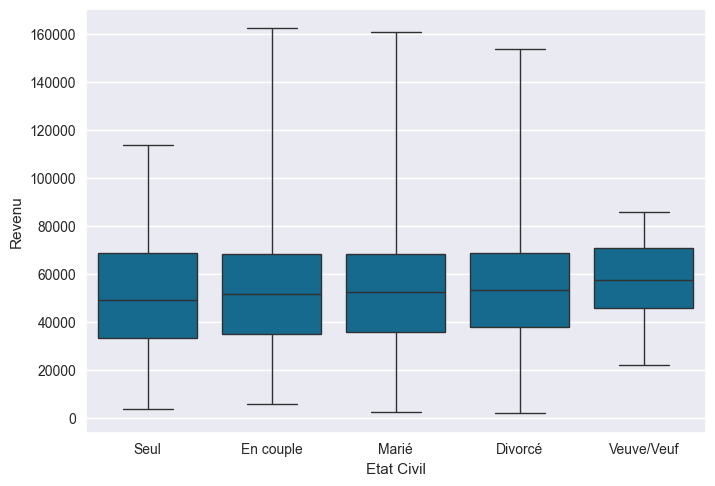

In [70]:
plt.figure()
sns.boxplot(data=df, x="Etat Civil", y="Revenu", whis=3)
plt.show()

Seul et Veuf, on à moins de chance d'avoir des sous. Le reste du temps, c'est un peu prét similaire.

### 7. Boxplot revenus par Diplôme


In [71]:
print(f"Nb valeurs diff : {df['Diplôme'].nunique()}")

Nb valeurs diff : 5


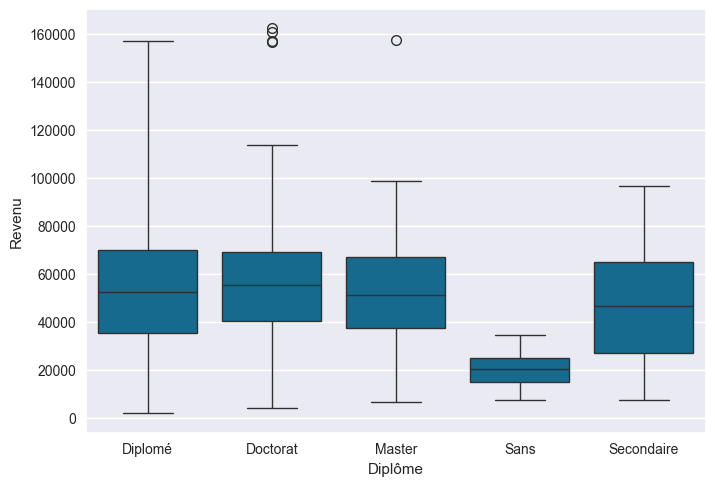

In [72]:
plt.figure()
sns.boxplot(data=df, x="Diplôme", y="Revenu", whis=3)
plt.show()

Le master sert à rien, sinon, plus on à de diplome plus on à de sous

### 8. Histplot Age / Revenu / Montant par diplôme


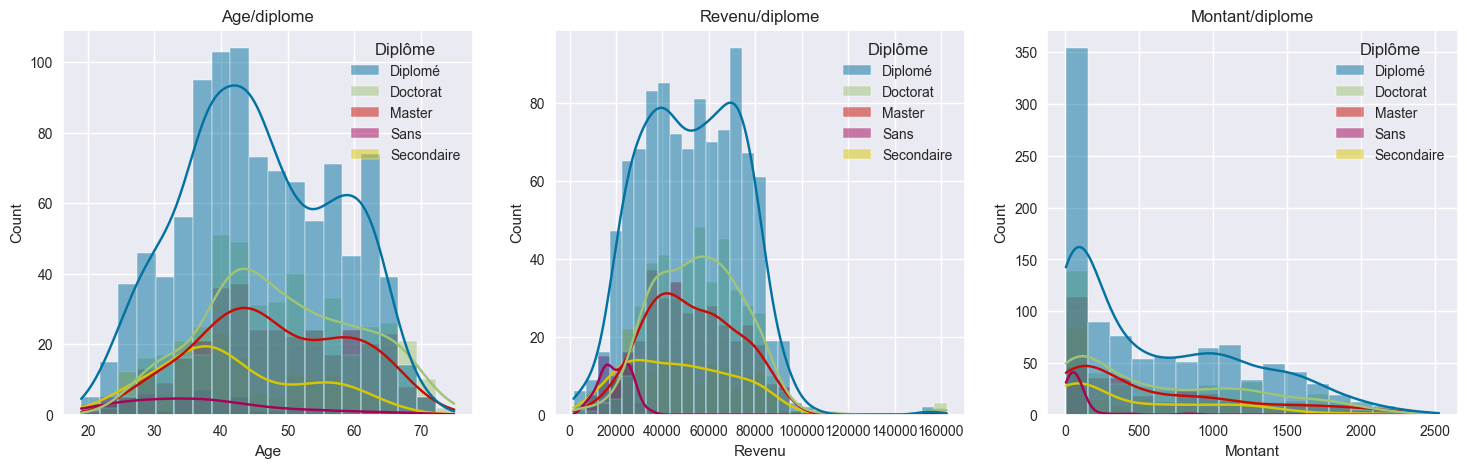

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(["Age", "Revenu", "Montant"]):
    sns.histplot(data=df, x=col, hue="Diplôme", kde=True, ax=axes[i])
    axes[i].set_title(f"{col}/diplome")
plt.show()

Les gens diplomé, vienne vers le milieu de leurs vie

Les gens vienne quand ils gagnes entre 20 000 et 90 000, et on à une recrudéscence vers 160 000

Le diplome influ pas/peu sur le montant.

### 9. Corrélation entre variables numériques


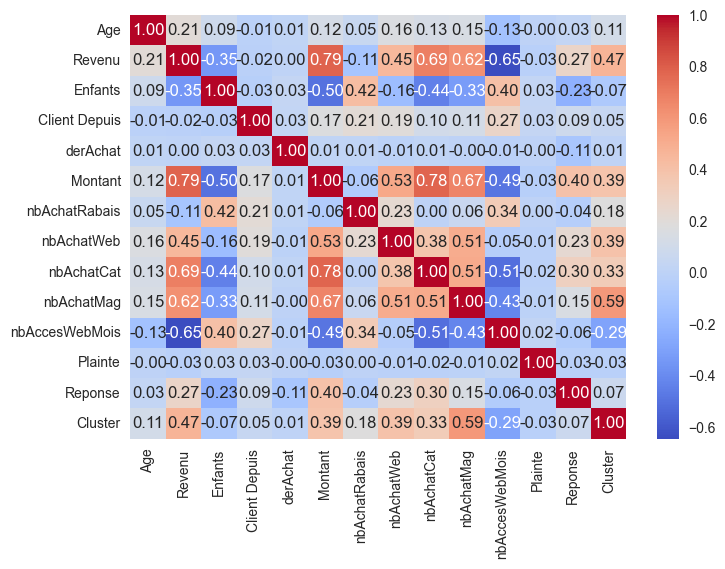

In [87]:
numeric_cols = df.select_dtypes(include=np.number)
plt.figure()
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

### 10. Réactivité aux campagnes marketing par Etat Civil


In [92]:
print(df.groupby("Etat Civil")["Reponse"].mean().sort_values(ascending=False))

Etat Civil
Veuve/Veuf    0.362319
Seul          0.318078
Divorcé       0.279621
En couple     0.255906
Marié         0.252241
Name: Reponse, dtype: float64


Les gens sont réactif quand ils ne sont pas attendu chez eux (veuf/ seul), plus ils sont attendu, moins ils répondent (exéption des divorcé qui sont en gros proche de la moyenne entre tous)

### 11. Montant moyen par Diplôme


In [94]:
print(df.groupby("Diplôme")["Montant"].mean().sort_values(ascending=False))

Diplôme
Doctorat      671.520737
Diplomé       625.449060
Master        609.302115
Secondaire    492.558011
Sans           83.918367
Name: Montant, dtype: float64


Plus on à de diplome, plus on dépense

## Exercice 2 : Clustering


### 1. Sélection des colonnes


In [97]:
clustering_cols = ["Age", "Revenu", "Montant", "nbAchatWeb", "nbAchatMag", "nbAccesWebMois"]
df_cluster = df[clustering_cols].copy()

### 2. Normalisation StandardScaler


In [99]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(df_scaled, columns=clustering_cols, index=df_cluster.index)

### 3. KMeans k=2 à 30 – évolution inertie


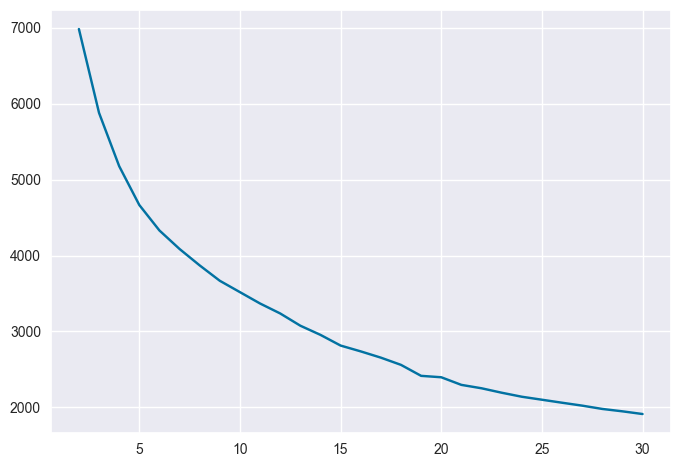

In [103]:
inertia = []

for k in range(2, 31):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df_scaled)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(range(2, 31), inertia)
plt.show()

Dans le creux, donc vers ~7

### 4. KElbowVisualizer


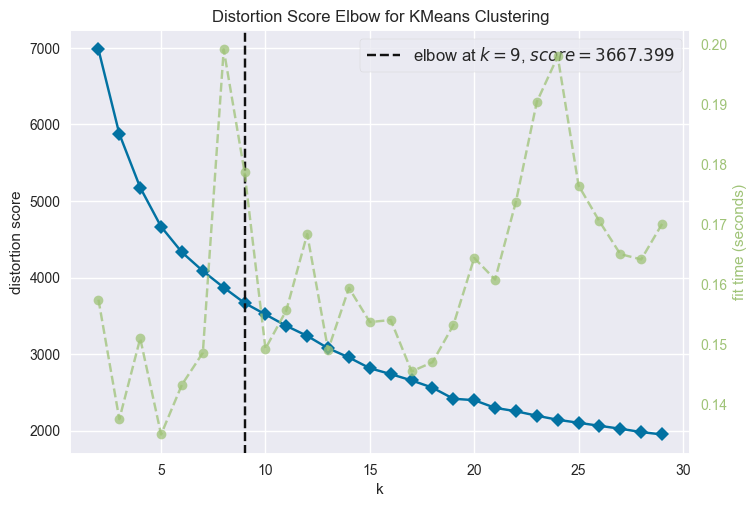

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [104]:
model = KMeans(n_clusters=2, random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(2, 30), force_model=True)
visualizer.fit(df_scaled)
visualizer.show()

Donc on à 9 en meilleur nb de cluster

### 5. KMeans avec le bon nombre de clusters


In [108]:
kmeans = KMeans(n_clusters=9, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df_scaled)

### 6. Moyennes par cluster


In [109]:
df.groupby("Cluster")[clustering_cols].mean()

,Age,Revenu,Montant,nbAchatWeb,nbAchatMag,nbAccesWebMois
Cluster,,,,,,
0,36.864516,27923.518280,69.488172,1.916129,2.810753,7.395699
1,57.353293,59864.347305,905.311377,8.664671,6.443114,6.251497
2,57.863636,39028.958333,116.428030,2.136364,3.375000,6.098485
3,34.079365,78027.878307,1442.962963,4.661376,8.814815,2.328042
4,54.087209,79898.017442,1311.075581,4.220930,5.593023,2.296512
5,42.281407,46251.160804,183.251256,2.165829,4.492462,3.899497
6,58.773481,70002.425414,1078.977901,4.668508,10.845304,3.248619
7,42.862069,47978.472906,453.566502,5.852217,5.566502,7.068966
8,42.475904,66325.536145,1098.891566,7.584337,10.421687,5.668675


### 7. Répartition des clients par cluster


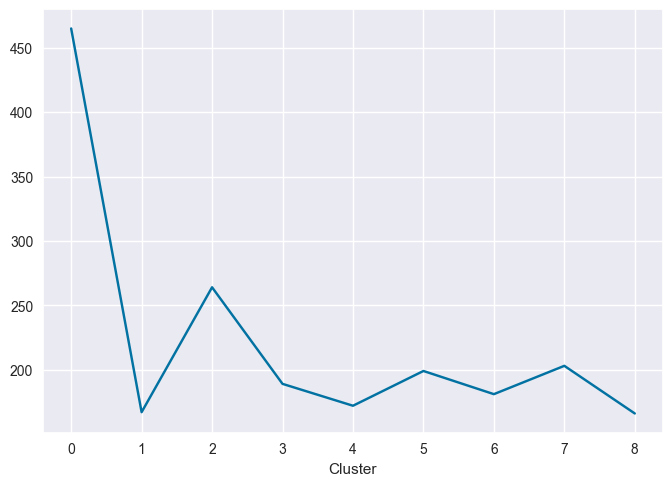

In [114]:
df["Cluster"].value_counts().sort_index().plot()
plt.show()

Le cluser 0 part au ciel, pour le reste, c'et un peu prés homogéne

### 8. Analyse des regroupements


### 9. Montant des achats et revenus par Cluster × Diplôme


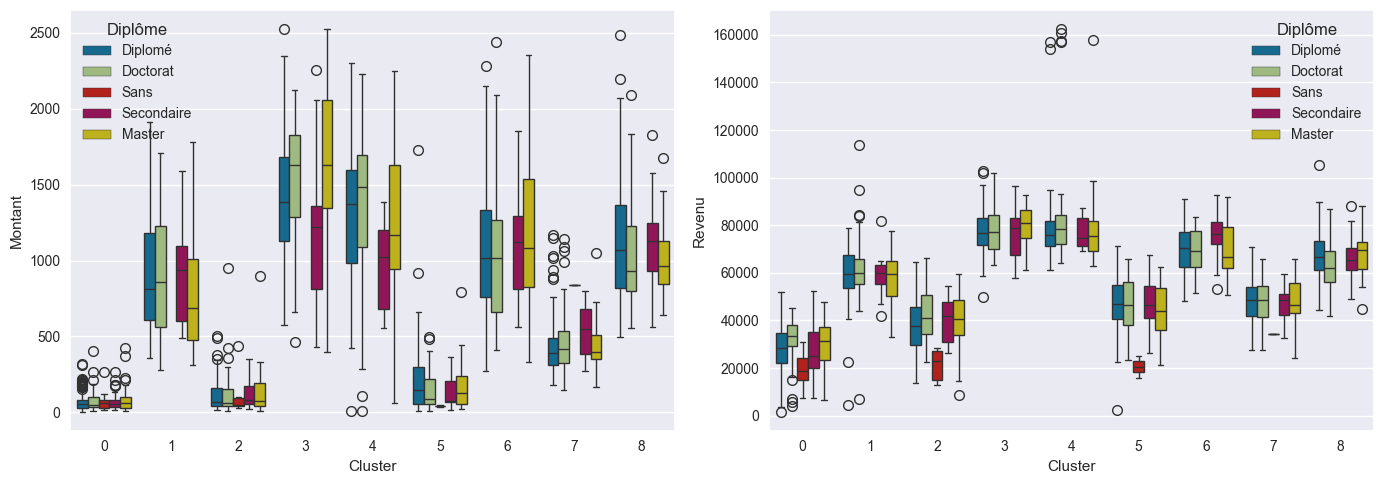

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Cluster", y="Montant", hue="Diplôme", ax=axes[0])

sns.boxplot(data=df, x="Cluster", y="Revenu", hue="Diplôme", ax=axes[1])

plt.tight_layout()
plt.show()

### 10. PCA – 2 vecteurs propres


In [125]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print(f"Variance : {pca.explained_variance_ratio_.sum():.2%}")

Variance : 69.61%


On à ~70% de variance, donc c'est un peu près ok

### 11. Revenus et dépenses par classe (PCA)


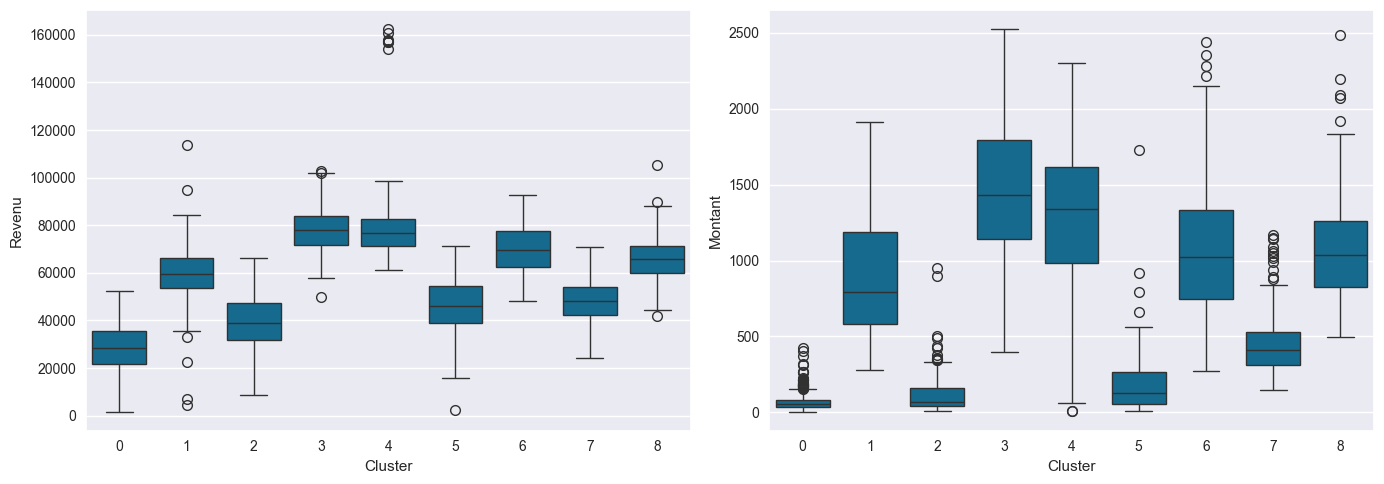

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Cluster", y="Revenu", ax=axes[0])

sns.boxplot(data=df, x="Cluster", y="Montant", ax=axes[1])

plt.tight_layout()
plt.show()

Les gens on des dépense assez dispersé, mais ça suis un peu près les revenu. J'en conclu qu'on à fait du plutot bon boulot

### 12. Répartition des classes sur les deux composantes PCA


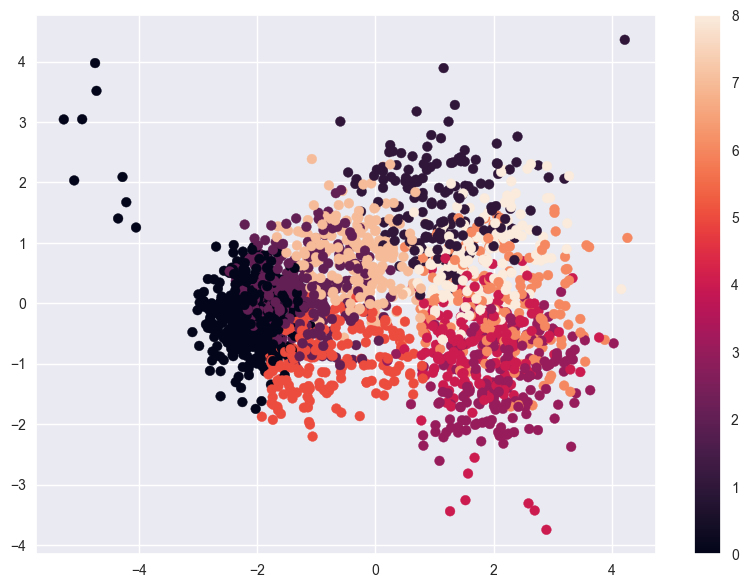

In [135]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df["Cluster"])
plt.colorbar(scatter)
plt.show()